In [ ]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

<b><font color="red" size="6">11_iris(다양한DNN)</font></b>

In [32]:
# import
import numpy as np
from sklearn import datasets
import pandas as pd # 원핫인코딩 pd.get_dummies
from sklearn.preprocessing import LabelEncoder # 라벨인코딩(문자->숫자)
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from sklearn.model_selection import train_test_split # 데이터분할(층화추출)
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Input, Dropout, add
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt # 학습과정 시각화

# 데이터 생성 및 전처리(라벨인코딩만 하고, 원핫인코딩X)

In [33]:
from sklearn import datasets
iris = datasets.load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
iris_X = iris.data
iris_y = iris.target # sklearn으로 iris를 가져오면 라벨인코딩이 이미 되어 있음
iris_X.shape, iris_y.shape
iris_y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [7]:
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                    test_size=0.1,
                                                    stratify=iris_y,
                                                    random_state=4)
train_X.shape,train_y.shape, test_X.shape,test_y.shape

((135, 4), (135,), (15, 4), (15,))

# 1. 기본적인 DNN(원핫인코딩X)

## 모델 설정

In [8]:
# 모델 설정
model = Sequential([Input(4,),
                    Dense(50, activation='relu'),
                    Dense(30, activation='relu'),
                    Dense(3, activation='softmax')])
model.summary() # 250+ 1530 + 93 = 1873개 파라미터

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                250       
                                                                 
 dense_1 (Dense)             (None, 30)                1530      
                                                                 
 dense_2 (Dense)             (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


## 학습 설정

In [9]:
# 학습 설정
model.compile(loss='sparse_categorical_crossentropy', # 라벨인코딩만 되어있는경우 sparse_를 붙히면 원핫인코딩을 해줌
              optimizer='adam',
              metrics=['accuracy'])

In [11]:
# 학습
earlyStopping = EarlyStopping(patience=50) # monitor='val_loss' 기본값
hist = model.fit(train_X, train_y, 
                 epochs=1000,
                 validation_split=0.2,
                 callbacks=[earlyStopping])

Epoch 1/1000
4/4 [==============================] - 1s 64ms/step - loss: 1.4401 - accuracy: 0.3426 - val_loss: 1.3682 - val_accuracy: 0.2963
Epoch 2/1000
4/4 [==============================] - 0s 12ms/step - loss: 1.3090 - accuracy: 0.3426 - val_loss: 1.2888 - val_accuracy: 0.2963
Epoch 3/1000
4/4 [==============================] - 0s 13ms/step - loss: 1.2105 - accuracy: 0.3426 - val_loss: 1.2288 - val_accuracy: 0.2963
Epoch 4/1000
4/4 [==============================] - 0s 13ms/step - loss: 1.1447 - accuracy: 0.3426 - val_loss: 1.1759 - val_accuracy: 0.2963
Epoch 5/1000
4/4 [==============================] - 0s 12ms/step - loss: 1.0834 - accuracy: 0.4259 - val_loss: 1.1239 - val_accuracy: 0.3704
Epoch 6/1000
4/4 [==============================] - 0s 12ms/step - loss: 1.0419 - accuracy: 0.4167 - val_loss: 1.0747 - val_accuracy: 0.2222
Epoch 7/1000
4/4 [==============================] - 0s 12ms/step - loss: 1.0002 - accuracy: 0.3611 - val_loss: 1.0229 - val_accuracy: 0.2222
Epoch 8/1000


Epoch 59/1000
4/4 [==============================] - 0s 13ms/step - loss: 0.2104 - accuracy: 0.9815 - val_loss: 0.1916 - val_accuracy: 0.9630
Epoch 60/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.2059 - accuracy: 0.9815 - val_loss: 0.1883 - val_accuracy: 0.9630
Epoch 61/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1998 - accuracy: 0.9815 - val_loss: 0.1907 - val_accuracy: 0.9630
Epoch 62/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1979 - accuracy: 0.9630 - val_loss: 0.1926 - val_accuracy: 0.9630
Epoch 63/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1955 - accuracy: 0.9630 - val_loss: 0.1863 - val_accuracy: 0.9630
Epoch 64/1000
4/4 [==============================] - 0s 13ms/step - loss: 0.1891 - accuracy: 0.9722 - val_loss: 0.1838 - val_accuracy: 0.9630
Epoch 65/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.1864 - accuracy: 0.9630 - val_loss: 0.1768 - val_accuracy: 0.9630
Epoch 

4/4 [==============================] - 0s 13ms/step - loss: 0.0721 - accuracy: 0.9815 - val_loss: 0.0930 - val_accuracy: 0.9259
Epoch 174/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0684 - accuracy: 0.9815 - val_loss: 0.0988 - val_accuracy: 0.9630
Epoch 175/1000
4/4 [==============================] - 0s 16ms/step - loss: 0.0716 - accuracy: 0.9815 - val_loss: 0.0987 - val_accuracy: 0.9630
Epoch 176/1000
4/4 [==============================] - 0s 15ms/step - loss: 0.0708 - accuracy: 0.9907 - val_loss: 0.0928 - val_accuracy: 0.9259
Epoch 177/1000
4/4 [==============================] - 0s 15ms/step - loss: 0.0674 - accuracy: 0.9815 - val_loss: 0.0926 - val_accuracy: 0.9259
Epoch 178/1000
4/4 [==============================] - 0s 14ms/step - loss: 0.0694 - accuracy: 0.9815 - val_loss: 0.0927 - val_accuracy: 0.9259
Epoch 179/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0698 - accuracy: 0.9815 - val_loss: 0.0924 - val_accuracy: 0.9259
Epoch 180/1000

4/4 [==============================] - 0s 12ms/step - loss: 0.0563 - accuracy: 0.9907 - val_loss: 0.0905 - val_accuracy: 0.9259
Epoch 288/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0545 - accuracy: 0.9907 - val_loss: 0.0899 - val_accuracy: 0.9259
Epoch 289/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0554 - accuracy: 0.9815 - val_loss: 0.0899 - val_accuracy: 0.9259
Epoch 290/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0568 - accuracy: 0.9815 - val_loss: 0.0904 - val_accuracy: 0.9259
Epoch 291/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0559 - accuracy: 0.9815 - val_loss: 0.0896 - val_accuracy: 0.9259
Epoch 292/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.0620 - accuracy: 0.9815 - val_loss: 0.0997 - val_accuracy: 0.9630
Epoch 293/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.0627 - accuracy: 0.9907 - val_loss: 0.0976 - val_accuracy: 0.9630
Epoch 294/1000

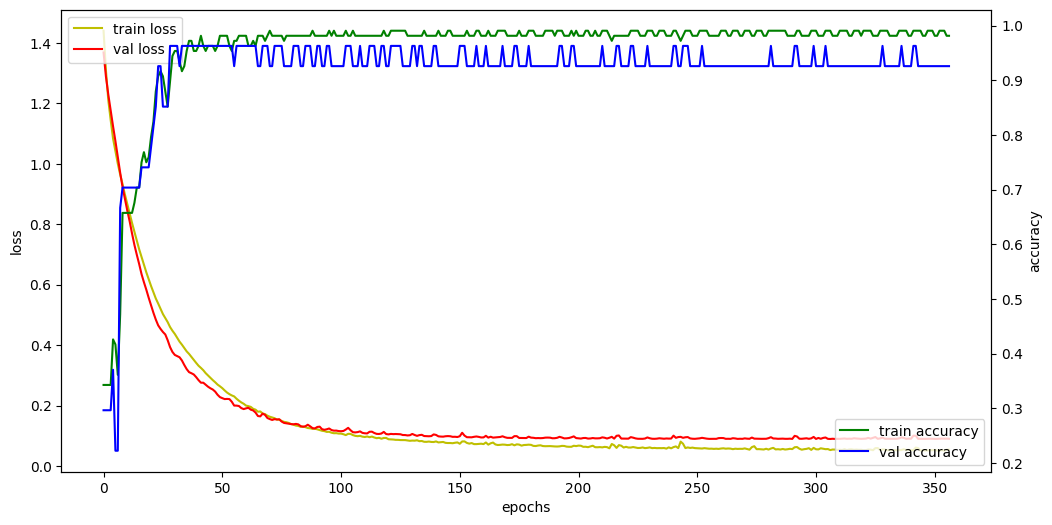

In [13]:
# 5. 모델 할습과정 시각화
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='upper left')
acc_ax.legend()
plt.show()

# 2. sklearn 이용
- 원핫인코딩을 하지 않고 라벨인코딩까지만 해야 작동. numpy배열

In [15]:
from sklearn.neural_network import MLPClassifier

### -- 머신러닝 3장 교안 43page 참조

In [16]:
# --머신러닝 3장 교안 43page 참조
mlp_model = MLPClassifier(hidden_layer_sizes=(50,30),
                     activation='relu',
                     solver='adam',
                     alpha=0.0001, # 과적합 방지 강도(기본값 0.0001)
                     batch_size=40,
                     max_iter=1000, # epochs 학습 횟수
                     early_stopping=True, # 조기종료 활성화(val_loss 기본값)
                     n_iter_no_change=50, # patience=50
                     warm_start=False, # True일 경우 이전학습에 이어서 학습
                     validation_fraction=0.1, # 검증셋 비율 
                     )

In [17]:
mlp_model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True, hidden_layer_sizes=(50, 30),
              max_iter=1000, n_iter_no_change=50)

### -- 모델 평가 : accuracy, recall, precision

In [24]:
# 모델 평가 : accuracy(test_X, test_y), recall, precision(test_y,yhat)
from sklearn.metrics import recall_score, precision_score
accuracy = mlp_model.score(test_X, test_y)
accuracy # 결과 1
yhat = mlp_model.predict(test_X)
yhat # 결과 array([0, 2, 1, 2, 2, 1, 2, 2, 0, 0, 0, 0, 1, 1, 1])
recall = recall_score(test_y, yhat, average='weighted')
recall # 결과 1
precision = precision_score(test_y, yhat, average='weighted')

print('정확도 :', accuracy)
print('재현율 :', recall)
print('정밀도 :', precision)
print('교차표\n', pd.crosstab(test_y, yhat, rownames=['실제'], colnames=['예측']))

정확도 : 1.0
재현율 : 1.0
정밀도 : 1.0
교차표
 예측  0  1  2
실제         
0   5  0  0
1   0  5  0
2   0  0  5


# 3. 클래스를 이용

In [28]:
class DNNClassfier:
    @staticmethod
    def build(input_dim=4, activation='relu', optimizer='adam'):
        #모델구성
        model = Sequential()
        model.add(Input(input_dim,))
        model.add(Dense(50, activation=activation))
        model.add(Dense(30, activation=activation))
        model.add(Dense(3, activation='softmax'))
        
        #모델 학습 설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer=optimizer,
                     metrics=['accuracy'])
        return model

In [29]:
# 모델
model = DNNClassfier.build(input_dim=4, activation='relu')
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 50)                250       
                                                                 
 dense_10 (Dense)            (None, 30)                1530      
                                                                 
 dense_11 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [30]:
# 모델 학습
hist = model.fit(train_X, train_y,
                epochs=500,
                validation_split=0.2)

Epoch 1/500
4/4 [==============================] - 0s 54ms/step - loss: 1.2095 - accuracy: 0.3426 - val_loss: 1.1921 - val_accuracy: 0.2963
Epoch 2/500
4/4 [==============================] - 0s 13ms/step - loss: 1.0827 - accuracy: 0.3426 - val_loss: 1.1158 - val_accuracy: 0.2963
Epoch 3/500
4/4 [==============================] - 0s 12ms/step - loss: 1.0182 - accuracy: 0.2778 - val_loss: 1.0551 - val_accuracy: 0.1852
Epoch 4/500
4/4 [==============================] - 0s 13ms/step - loss: 0.9614 - accuracy: 0.3611 - val_loss: 1.0096 - val_accuracy: 0.2222
Epoch 5/500
4/4 [==============================] - 0s 13ms/step - loss: 0.9288 - accuracy: 0.3611 - val_loss: 0.9638 - val_accuracy: 0.2963
Epoch 6/500
4/4 [==============================] - 0s 13ms/step - loss: 0.9018 - accuracy: 0.4815 - val_loss: 0.9229 - val_accuracy: 0.6667
Epoch 7/500
4/4 [==============================] - 0s 13ms/step - loss: 0.8771 - accuracy: 0.6389 - val_loss: 0.8784 - val_accuracy: 0.7037
Epoch 8/500
4/4 [===

4/4 [==============================] - 0s 11ms/step - loss: 0.1070 - accuracy: 0.9815 - val_loss: 0.0817 - val_accuracy: 1.0000
Epoch 118/500
4/4 [==============================] - 0s 11ms/step - loss: 0.1051 - accuracy: 0.9815 - val_loss: 0.0828 - val_accuracy: 1.0000
Epoch 119/500
4/4 [==============================] - 0s 13ms/step - loss: 0.1064 - accuracy: 0.9815 - val_loss: 0.0840 - val_accuracy: 0.9630
Epoch 120/500
4/4 [==============================] - 0s 16ms/step - loss: 0.1052 - accuracy: 0.9815 - val_loss: 0.0799 - val_accuracy: 1.0000
Epoch 121/500
4/4 [==============================] - 0s 13ms/step - loss: 0.1026 - accuracy: 0.9815 - val_loss: 0.0792 - val_accuracy: 1.0000
Epoch 122/500
4/4 [==============================] - 0s 16ms/step - loss: 0.1006 - accuracy: 0.9815 - val_loss: 0.0805 - val_accuracy: 1.0000
Epoch 123/500
4/4 [==============================] - 0s 15ms/step - loss: 0.1017 - accuracy: 0.9815 - val_loss: 0.0800 - val_accuracy: 1.0000
Epoch 124/500
4/4 [=

Epoch 175/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0725 - accuracy: 0.9815 - val_loss: 0.0654 - val_accuracy: 0.9630
Epoch 176/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0749 - accuracy: 0.9815 - val_loss: 0.0713 - val_accuracy: 0.9630
Epoch 177/500
4/4 [==============================] - 0s 15ms/step - loss: 0.0782 - accuracy: 0.9815 - val_loss: 0.0675 - val_accuracy: 0.9630
Epoch 178/500
4/4 [==============================] - 0s 14ms/step - loss: 0.0730 - accuracy: 0.9815 - val_loss: 0.0651 - val_accuracy: 1.0000
Epoch 179/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0773 - accuracy: 0.9815 - val_loss: 0.0669 - val_accuracy: 0.9630
Epoch 180/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0707 - accuracy: 0.9815 - val_loss: 0.0658 - val_accuracy: 0.9630
Epoch 181/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0831 - accuracy: 0.9722 - val_loss: 0.0679 - val_accuracy: 0.9630
Epoch 

Epoch 233/500
4/4 [==============================] - 0s 16ms/step - loss: 0.0635 - accuracy: 0.9815 - val_loss: 0.0665 - val_accuracy: 0.9630
Epoch 234/500
4/4 [==============================] - 0s 14ms/step - loss: 0.0643 - accuracy: 0.9815 - val_loss: 0.0663 - val_accuracy: 0.9630
Epoch 235/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0605 - accuracy: 0.9815 - val_loss: 0.0654 - val_accuracy: 0.9259
Epoch 236/500
4/4 [==============================] - 0s 15ms/step - loss: 0.0626 - accuracy: 0.9815 - val_loss: 0.0671 - val_accuracy: 0.9630
Epoch 237/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0632 - accuracy: 0.9815 - val_loss: 0.0668 - val_accuracy: 0.9630
Epoch 238/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0622 - accuracy: 0.9815 - val_loss: 0.0658 - val_accuracy: 0.9630
Epoch 239/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0607 - accuracy: 0.9815 - val_loss: 0.0657 - val_accuracy: 0.9259
Epoch 

Epoch 291/500
4/4 [==============================] - 0s 14ms/step - loss: 0.0539 - accuracy: 0.9907 - val_loss: 0.0696 - val_accuracy: 0.9259
Epoch 292/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0574 - accuracy: 0.9815 - val_loss: 0.0706 - val_accuracy: 0.9630
Epoch 293/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0544 - accuracy: 0.9815 - val_loss: 0.0726 - val_accuracy: 0.9630
Epoch 294/500
4/4 [==============================] - 0s 14ms/step - loss: 0.0577 - accuracy: 0.9815 - val_loss: 0.0753 - val_accuracy: 0.9630
Epoch 295/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0567 - accuracy: 0.9907 - val_loss: 0.0703 - val_accuracy: 0.9259
Epoch 296/500
4/4 [==============================] - 0s 14ms/step - loss: 0.0530 - accuracy: 0.9907 - val_loss: 0.0699 - val_accuracy: 0.9259
Epoch 297/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0585 - accuracy: 0.9815 - val_loss: 0.0702 - val_accuracy: 0.9259
Epoch 

Epoch 349/500
4/4 [==============================] - 0s 15ms/step - loss: 0.0498 - accuracy: 0.9907 - val_loss: 0.0745 - val_accuracy: 0.9259
Epoch 350/500
4/4 [==============================] - 0s 14ms/step - loss: 0.0497 - accuracy: 0.9907 - val_loss: 0.0745 - val_accuracy: 0.9259
Epoch 351/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0501 - accuracy: 0.9907 - val_loss: 0.0762 - val_accuracy: 0.9259
Epoch 352/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0515 - accuracy: 0.9907 - val_loss: 0.0750 - val_accuracy: 0.9259
Epoch 353/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0493 - accuracy: 0.9907 - val_loss: 0.0758 - val_accuracy: 0.9259
Epoch 354/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0496 - accuracy: 0.9907 - val_loss: 0.0756 - val_accuracy: 0.9259
Epoch 355/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0502 - accuracy: 0.9907 - val_loss: 0.0757 - val_accuracy: 0.9259
Epoch 

Epoch 407/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0460 - accuracy: 0.9907 - val_loss: 0.0806 - val_accuracy: 0.9259
Epoch 408/500
4/4 [==============================] - 0s 14ms/step - loss: 0.0474 - accuracy: 0.9907 - val_loss: 0.0816 - val_accuracy: 0.9259
Epoch 409/500
4/4 [==============================] - 0s 14ms/step - loss: 0.0475 - accuracy: 0.9907 - val_loss: 0.0808 - val_accuracy: 0.9259
Epoch 410/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0460 - accuracy: 0.9907 - val_loss: 0.0831 - val_accuracy: 0.9259
Epoch 411/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0471 - accuracy: 0.9907 - val_loss: 0.0824 - val_accuracy: 0.9259
Epoch 412/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0476 - accuracy: 0.9907 - val_loss: 0.0811 - val_accuracy: 0.9259
Epoch 413/500
4/4 [==============================] - 0s 15ms/step - loss: 0.0461 - accuracy: 0.9907 - val_loss: 0.0835 - val_accuracy: 0.9259
Epoch 

Epoch 465/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0451 - accuracy: 0.9907 - val_loss: 0.0855 - val_accuracy: 0.9259
Epoch 466/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0447 - accuracy: 0.9907 - val_loss: 0.0857 - val_accuracy: 0.9259
Epoch 467/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0445 - accuracy: 0.9907 - val_loss: 0.0861 - val_accuracy: 0.9259
Epoch 468/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0456 - accuracy: 0.9907 - val_loss: 0.0911 - val_accuracy: 0.9259
Epoch 469/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0458 - accuracy: 0.9815 - val_loss: 0.0868 - val_accuracy: 0.9259
Epoch 470/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0461 - accuracy: 0.9907 - val_loss: 0.0867 - val_accuracy: 0.9259
Epoch 471/500
4/4 [==============================] - 0s 20ms/step - loss: 0.0459 - accuracy: 0.9907 - val_loss: 0.0861 - val_accuracy: 0.9259
Epoch 

In [31]:
loss, accuracy = model.evaluate(test_X, test_y)
loss, accuracy

1/1 [==============================] - 0s 29ms/step - loss: 0.0394 - accuracy: 1.0000


(0.03943183273077011, 1.0)

# 4. 함수형 API 이용하기
- 병렬처리 : 속도 높이려고 
- 레지듀얼블럭(Residual block) : 모델의 성능을 높이려고(자연어처리, 이미지처리)

In [34]:
# import
import numpy as np
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras import Model # 모델 생성(입력층과 출력층을 이용)
from tensorflow.keras.layers import Dense, Input, add # add :레지듀얼블록 
from tensorflow.keras.layers import concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt # 학습과정 시각화

In [35]:
from sklearn import datasets
iris = datasets.load_iris()
iris.keys()
iris_X = iris.data
iris_y = iris.target # sklearn으로 iris를 가져오면 라벨인코딩이 이미 되어 있음
iris_X.shape, iris_y.shape
iris_y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [36]:
# 기존의 model 스타일 4 -> 50 -> 30 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(50, activation='relu')(input_)
dense2 = Dense(30, activation='relu')(dense1)
dense3 = Dense(3, activation='softmax')(dense2)

model = Model(inputs=input_, outputs=dense3)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense_12 (Dense)            (None, 50)                250       
                                                                 
 dense_13 (Dense)            (None, 30)                1530      
                                                                 
 dense_14 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [37]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'],
             )
model.fit(train_X, train_y, epochs=20, validation_split=.2)

Epoch 1/20
4/4 [==============================] - 1s 63ms/step - loss: 0.9260 - accuracy: 0.4167 - val_loss: 0.9408 - val_accuracy: 0.2222
Epoch 2/20
4/4 [==============================] - 0s 13ms/step - loss: 0.8465 - accuracy: 0.5556 - val_loss: 0.8327 - val_accuracy: 0.7037
Epoch 3/20
4/4 [==============================] - 0s 15ms/step - loss: 0.7943 - accuracy: 0.6667 - val_loss: 0.7594 - val_accuracy: 0.7037
Epoch 4/20
4/4 [==============================] - 0s 13ms/step - loss: 0.7501 - accuracy: 0.6574 - val_loss: 0.7002 - val_accuracy: 0.7037
Epoch 5/20
4/4 [==============================] - 0s 12ms/step - loss: 0.7054 - accuracy: 0.6667 - val_loss: 0.6516 - val_accuracy: 0.7037
Epoch 6/20
4/4 [==============================] - 0s 14ms/step - loss: 0.6657 - accuracy: 0.6852 - val_loss: 0.6137 - val_accuracy: 0.7037
Epoch 7/20
4/4 [==============================] - 0s 12ms/step - loss: 0.6313 - accuracy: 0.6852 - val_loss: 0.5836 - val_accuracy: 0.7037
Epoch 8/20
4/4 [===========

## 병렬처리

In [38]:
# 병렬처리
# 4 -> 160(50, 80, 30로 병렬처리) -> 32 -> 3
input_ = Input(shape=(4,))
dense1 = Dense(50, activation = 'relu')(input_)
dense2 = Dense(80, activation = 'relu')(input_)
dense3 = Dense(30, activation = 'relu')(input_)

x = concatenate([dense1, dense2, dense3])
# x = Dense(160, activation='relu')(input_)의 병렬처리와 똑같음
dense4 = Dense(32, activation='relu')(x)

output = Dense(3, activation = 'softmax')(x)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 4)]          0           []                               
                                                                                                  
 dense_15 (Dense)               (None, 50)           250         ['input_6[0][0]']                
                                                                                                  
 dense_16 (Dense)               (None, 80)           400         ['input_6[0][0]']                
                                                                                                  
 dense_17 (Dense)               (None, 30)           150         ['input_6[0][0]']                
                                                                                            

## 레지듀얼블록(Residual Block) : 딥러닝에서 딥한 네트워크가 학습이 잘 되지 않을 때

In [40]:
# 레지듀얼블록(Residual Block) : 딥러닝에서 딥한 네트워크가 학습이 잘 되지 않을 때
# 4 -> 50 -> 50 -> (레지듀얼블록) -> 3
input_ = Input(shape=(4,))
dense1 = Dense(50, activation = 'relu')(input_)
dense2 = Dense(50, activation = 'relu')(dense1)

dense3 = add([dense1, dense2])

output = Dense(3, activation='softmax')(dense3)

model = Model(inputs=input_, outputs=output)
model.summary()

model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
model.fit(train_X, train_y, epochs=500, validation_split=0.2, verbose=1)

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 4)]          0           []                               
                                                                                                  
 dense_20 (Dense)               (None, 50)           250         ['input_7[0][0]']                
                                                                                                  
 dense_21 (Dense)               (None, 50)           2550        ['dense_20[0][0]']               
                                                                                                  
 add (Add)                      (None, 50)           0           ['dense_20[0][0]',               
                                                                  'dense_21[0][0]']         

4/4 [==============================] - 0s 12ms/step - loss: 0.1082 - accuracy: 0.9815 - val_loss: 0.1181 - val_accuracy: 0.9259
Epoch 106/500
4/4 [==============================] - 0s 13ms/step - loss: 0.1090 - accuracy: 0.9815 - val_loss: 0.1193 - val_accuracy: 0.9630
Epoch 107/500
4/4 [==============================] - 0s 14ms/step - loss: 0.1060 - accuracy: 0.9815 - val_loss: 0.1180 - val_accuracy: 0.9630
Epoch 108/500
4/4 [==============================] - 0s 15ms/step - loss: 0.1053 - accuracy: 0.9815 - val_loss: 0.1176 - val_accuracy: 0.9630
Epoch 109/500
4/4 [==============================] - 0s 13ms/step - loss: 0.1050 - accuracy: 0.9815 - val_loss: 0.1197 - val_accuracy: 0.9630
Epoch 110/500
4/4 [==============================] - 0s 14ms/step - loss: 0.1046 - accuracy: 0.9815 - val_loss: 0.1191 - val_accuracy: 0.9630
Epoch 111/500
4/4 [==============================] - 0s 14ms/step - loss: 0.1035 - accuracy: 0.9815 - val_loss: 0.1268 - val_accuracy: 0.9630
Epoch 112/500
4/4 [=

Epoch 163/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0773 - accuracy: 0.9815 - val_loss: 0.0926 - val_accuracy: 0.9630
Epoch 164/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0740 - accuracy: 0.9907 - val_loss: 0.0911 - val_accuracy: 0.9259
Epoch 165/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0747 - accuracy: 0.9907 - val_loss: 0.0935 - val_accuracy: 0.9630
Epoch 166/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0730 - accuracy: 0.9815 - val_loss: 0.0948 - val_accuracy: 0.9630
Epoch 167/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0731 - accuracy: 0.9815 - val_loss: 0.0937 - val_accuracy: 0.9630
Epoch 168/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0731 - accuracy: 0.9907 - val_loss: 0.0905 - val_accuracy: 0.9259
Epoch 169/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0732 - accuracy: 0.9907 - val_loss: 0.0902 - val_accuracy: 0.9259
Epoch 

Epoch 221/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0632 - accuracy: 0.9907 - val_loss: 0.0863 - val_accuracy: 0.9630
Epoch 222/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0603 - accuracy: 0.9907 - val_loss: 0.0845 - val_accuracy: 0.9259
Epoch 223/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0624 - accuracy: 0.9815 - val_loss: 0.0843 - val_accuracy: 0.9259
Epoch 224/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0611 - accuracy: 0.9907 - val_loss: 0.0855 - val_accuracy: 0.9630
Epoch 225/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0606 - accuracy: 0.9907 - val_loss: 0.0869 - val_accuracy: 0.9630
Epoch 226/500
4/4 [==============================] - 0s 15ms/step - loss: 0.0622 - accuracy: 0.9907 - val_loss: 0.0866 - val_accuracy: 0.9630
Epoch 227/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0594 - accuracy: 0.9907 - val_loss: 0.0839 - val_accuracy: 0.9259
Epoch 

Epoch 279/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0558 - accuracy: 0.9907 - val_loss: 0.0836 - val_accuracy: 0.9259
Epoch 280/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0559 - accuracy: 0.9907 - val_loss: 0.0835 - val_accuracy: 0.9259
Epoch 281/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0547 - accuracy: 0.9907 - val_loss: 0.0828 - val_accuracy: 0.9259
Epoch 282/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0548 - accuracy: 0.9907 - val_loss: 0.0835 - val_accuracy: 0.9259
Epoch 283/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0546 - accuracy: 0.9907 - val_loss: 0.0852 - val_accuracy: 0.9259
Epoch 284/500
4/4 [==============================] - 0s 15ms/step - loss: 0.0575 - accuracy: 0.9907 - val_loss: 0.0843 - val_accuracy: 0.9259
Epoch 285/500
4/4 [==============================] - 0s 19ms/step - loss: 0.0530 - accuracy: 0.9907 - val_loss: 0.0877 - val_accuracy: 0.9259
Epoch 

Epoch 337/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0517 - accuracy: 0.9907 - val_loss: 0.0852 - val_accuracy: 0.9259
Epoch 338/500
4/4 [==============================] - 0s 14ms/step - loss: 0.0516 - accuracy: 0.9907 - val_loss: 0.0842 - val_accuracy: 0.9259
Epoch 339/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0552 - accuracy: 0.9815 - val_loss: 0.0839 - val_accuracy: 0.9259
Epoch 340/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0522 - accuracy: 0.9907 - val_loss: 0.0840 - val_accuracy: 0.9259
Epoch 341/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0527 - accuracy: 0.9907 - val_loss: 0.0858 - val_accuracy: 0.9630
Epoch 342/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0555 - accuracy: 0.9907 - val_loss: 0.0841 - val_accuracy: 0.9259
Epoch 343/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0493 - accuracy: 0.9907 - val_loss: 0.0879 - val_accuracy: 0.9259
Epoch 

Epoch 395/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0498 - accuracy: 0.9907 - val_loss: 0.0838 - val_accuracy: 0.9259
Epoch 396/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0490 - accuracy: 0.9907 - val_loss: 0.0840 - val_accuracy: 0.9259
Epoch 397/500
4/4 [==============================] - 0s 13ms/step - loss: 0.0500 - accuracy: 0.9907 - val_loss: 0.0861 - val_accuracy: 0.9259
Epoch 398/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0482 - accuracy: 0.9907 - val_loss: 0.0863 - val_accuracy: 0.9259
Epoch 399/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0510 - accuracy: 0.9815 - val_loss: 0.0876 - val_accuracy: 0.9259
Epoch 400/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0512 - accuracy: 0.9815 - val_loss: 0.0891 - val_accuracy: 0.9259
Epoch 401/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0527 - accuracy: 0.9815 - val_loss: 0.0911 - val_accuracy: 0.9259
Epoch 

Epoch 453/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0485 - accuracy: 0.9907 - val_loss: 0.0866 - val_accuracy: 0.9259
Epoch 454/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0469 - accuracy: 0.9907 - val_loss: 0.0914 - val_accuracy: 0.9259
Epoch 455/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0584 - accuracy: 0.9815 - val_loss: 0.0910 - val_accuracy: 0.9259
Epoch 456/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0479 - accuracy: 0.9815 - val_loss: 0.0898 - val_accuracy: 0.9259
Epoch 457/500
4/4 [==============================] - 0s 12ms/step - loss: 0.0463 - accuracy: 0.9907 - val_loss: 0.0943 - val_accuracy: 0.9630
Epoch 458/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0499 - accuracy: 0.9907 - val_loss: 0.0926 - val_accuracy: 0.9630
Epoch 459/500
4/4 [==============================] - 0s 11ms/step - loss: 0.0485 - accuracy: 0.9907 - val_loss: 0.0884 - val_accuracy: 0.9259
Epoch 

In [41]:
model.evaluate(test_X, test_y)

1/1 [==============================] - 0s 32ms/step - loss: 0.0603 - accuracy: 0.9333


[0.06034642085433006, 0.9333333373069763]